In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

histogramlim = 10000
binwidth = 50

In [ ]:
# Desired dummy offset
offset = -3000
channel = 'r'
dummyname = f'{channel}{str(offset)}.tsv'

df = pd.DataFrame(columns = ['portID', 'slaveID', 'chipID', 'channelID', 'tOffset'])

for l in range(128):
    if channel == 'l':
        df = pd.concat([df, pd.DataFrame([[0, 0, l // 64, l % 64, offset]], columns = ['portID', 'slaveID', 'chipID', 'channelID', 'tOffset'])], ignore_index=True)
    else:
        df = pd.concat([df, pd.DataFrame([[0, 0, l // 64, l % 64, 0]], columns = ['portID', 'slaveID', 'chipID', 'channelID', 'tOffset'])], ignore_index=True)

for r in range(896,1024):
    if channel == 'r':
        df = pd.concat([df, pd.DataFrame([[0, 0, r // 64, r % 64, offset]], columns = ['portID', 'slaveID', 'chipID', 'channelID', 'tOffset'])], ignore_index=True)
    else:
        df = pd.concat([df, pd.DataFrame([[0, 0, r // 64, r % 64, 0]], columns = ['portID', 'slaveID', 'chipID', 'channelID', 'tOffset'])], ignore_index=True)

df.to_csv('C:/Users/burri/Downloads/' + dummyname, sep = '\t', header = None, index = False)

In [3]:
# Read calibration data into pd DataFrame
df = pd.DataFrame()
for chunk in pd.read_csv('C:/Users/burri/Downloads/VerticalMotion_HighIntSource_800sec_coinc.dat', usecols=[2, 4, 7, 9], delimiter="\t", header=None, chunksize=10000):
    # Name columns
    chunk.columns = ['TimeL', 'IDL', 'TimeR', 'IDR']
    # Time difference column
    chunk['TimeDiff'] = chunk['TimeL'] - chunk['TimeR']
    
    df = pd.concat([df, chunk], ignore_index=True)

# Convert to numpy array, faster
arr = df.to_numpy()

master_time_diffs = []
for x in arr:
    master_time_diffs.append(x[4])
print(len(master_time_diffs))

3517415


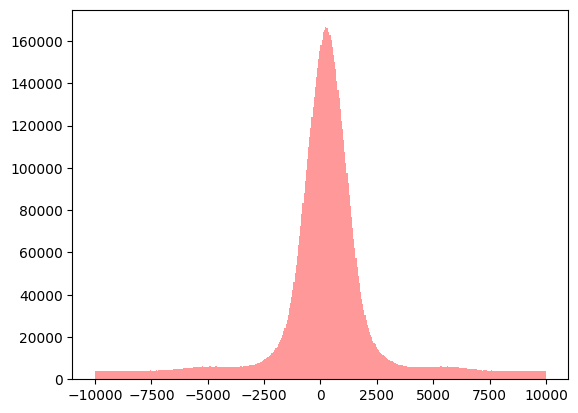

In [6]:
# Histogram before time calibration
histogramlim = 10000
binwidth = 50

hist_before = plt.hist(master_time_diffs, bins=range(int(min(master_time_diffs)), int(max(master_time_diffs)) + binwidth, binwidth), color = 'red', alpha = 0.4)

In [4]:
# Read calibrated data
df = pd.DataFrame()
for chunk in pd.read_csv('C:/Users/burri/Downloads/VerticalMotion_HighIntSource_800sec_2_calibrationtest2_coinc.dat', usecols=[2, 4, 7, 9], delimiter="\t", header=None, chunksize=10000):
    # Name columns
    chunk.columns = ['TimeL', 'IDL', 'TimeR', 'IDR']
    # Convert Left channel to mod 128
    chunk['IDL'] = chunk['IDL'] % 128
    # Time difference column
    chunk['TimeDiff'] = chunk['TimeL'] - chunk['TimeR']
    
    df = pd.concat([df, chunk], ignore_index=True)

# Convert to numpy array, faster
arr1 = df.to_numpy()

master_time_diffs1 = []
for x in arr1:
    master_time_diffs1.append(x[4])
print(len(master_time_diffs1))



3538485


[ 5.74095464e+03 -4.74770740e+03  1.62826308e+03  2.73945303e+04
  5.93116003e+00  1.17206242e+03  6.17193830e+03  4.91488142e+03
  1.66427986e+03  2.31261141e+03]
[ 6766.31704656 -3704.36543889  3164.98797102 45230.29609725
   113.89048457   569.36164006  7595.09010785  4769.42438197
  2458.04481793   696.46743706]


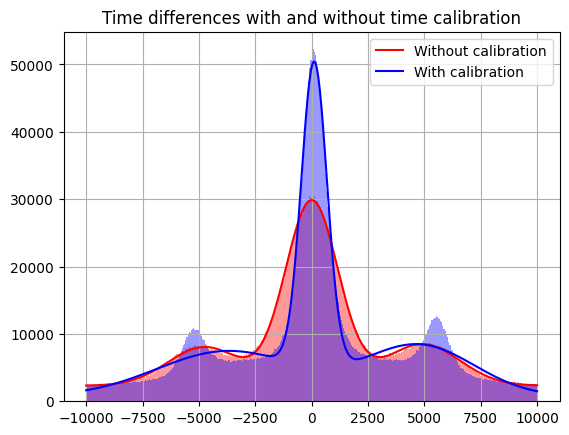

In [6]:
# Time difference histograms
histogramlim = 10000
binwidth = 50

# Define gaussian fit
def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))

# Triple guassian
def triplegaussian(x, a1, mu1, c1, a2, mu2, c2, a3, mu3, c3, noise):
    return a1*np.exp(-(x-mu1)**2/(2*c1**2)) + a2*np.exp(-(x-mu2)**2/(2*c2**2)) + a3*np.exp(-(x-mu3)**2/(2*c3**2)) + noise

def formatlabel(a, mu, c):
    return f'a={round(a)} μ={round(mu,1)} σ={round(abs(c),1)}'

# Histogram before time calibration
hist_before = plt.hist(master_time_diffs, bins=range(int(min(master_time_diffs)), int(max(master_time_diffs)) + binwidth, binwidth), color = 'red', alpha = 0.4)
bincenters0 = [(hist_before[1][x]+hist_before[1][x+1])/2 for x in range(len(hist_before[0]))]
popt0 = curve_fit(triplegaussian, bincenters0, hist_before[0], p0 = [6000, -5000, 1600, 30000, 0, 1000, 6000, 5000, 1600, 2500])[0]
plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), triplegaussian(np.linspace(-1*histogramlim, histogramlim, 300), *popt0), color = 'red', label = 'Without calibration')
print(popt0)

# Histogram of dummy data
hist_dummy = plt.hist(master_time_diffs1, bins=range(int(min(master_time_diffs1)), int(max(master_time_diffs1)) + binwidth, binwidth), color = 'blue', alpha = 0.4)
bincenters1 = [(hist_dummy[1][x]+hist_dummy[1][x+1])/2 for x in range(len(hist_dummy[0]))]
popt1 = curve_fit(triplegaussian, bincenters1, hist_dummy[0], p0 = [6000, -5000, 1600, 30000, 0, 1000, 6000, 5000, 1600, 2500])[0]
plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), triplegaussian(np.linspace(-1*histogramlim, histogramlim, 300), *popt1), color = 'blue', label = 'With calibration')
print(popt1)

plt.legend()
plt.title('Time differences with and without time calibration')
plt.grid()
#plt.savefig('C:/Users/burri/Downloads/' + 'timecalibrationtest3.png')
plt.show()

In [28]:
for x in range(10):
    print(round(popt0[x], 1), '\t', round(popt1[x], 1))

5371.0 	 5973.1
-4671.2 	 -4229.8
1605.9 	 2123.4
27304.6 	 35734.4
65.5 	 47.8
1170.3 	 815.1
6320.5 	 6895.1
4939.2 	 4422.1
1691.2 	 2265.0
2396.5 	 1694.2


In [57]:
check = 4
print(arr[check][0], arr[check][2], arr[check][0] - arr[check][2])
print(arr1[check][0], arr1[check][2], arr1[check][0] - arr1[check][2])

890541085888 890541084691 1197
890541086268 890541085576 692


In [ ]:
# TPPT Geometry checker

TPPT_geo_map_dir = 'C:/Users/burri/Downloads/TPPT_Scanner_mapcopy.csv'
# Geometric time offset matrix, stores time difference corresponding to the geometric center for each LOR
# each row corresponds to a left channel, each col to a right channel, such that each entry is a unique LOR
geometric_time_offsets = [[0 for i in range(3072)] for j in range(3072)]

# Read map
mapdf = pd.read_csv(TPPT_geo_map_dir, usecols=[0,1,2], header=None)
map = mapdf.to_numpy()
totalcount = 0

for l in range(3072):
    for r in range(3072):

        xL, yL, zL = map[l]
        xR, yR, zR = map[r+3072]
        # Get midpoint between two channels
        mX, mY, mZ = (xL+xR)/2, (yL+yR)/2, (zL+zR)/2

        # If midpoint lies on x = 0, write to table
        if mX == 0:
            geometric_time_offsets[l][r] = 0
        # else need to calculate distance between x = 0 and midpoint along LOR
        else:
            # Parameterize, below are slopes with x being the parameter
            ay, az = (yR-yL)/(xR-xL), (zR-zL)/(xR-xL)
            # Find y and z for positive distance xL away from xL (x = 0)
            y0, z0 = yL + ay * -1 * xL, zL + az * -1 * xL
            # Distance, converted to light picoseconds
            d = ((mX)**2 + (y0-mY)**2 + (z0-mZ)**2)**0.5 / 0.299792458 #mm/ps
            # Find direction (midpoint left or right from x=0)
            if -1 * xL > xR:
                geometric_time_offsets[l][r] = -1 * d
            else:
                geometric_time_offsets[l][r] = d



-2.258324929016453e-05


In [2]:
# TPPT
# Without calibration
center_source_data_dir_BOTTOM = 'C:/Users/burri/Documents/PET/TimeCalibration/TimeCalibrationTPPT/MovingSource_LowInt_60s_Bottom_2_HWTrigOff_coinc.dat'
center_source_data_dir_TOP = 'C:/Users/burri/Documents/PET/TimeCalibration/TimeCalibrationTPPT/MovingSource_LowInt_60s_Top_2_HWTrigOff_coinc.dat'

# Read calibration data into pd DataFrame
df = pd.DataFrame()
for chunk in pd.read_csv(center_source_data_dir_BOTTOM, usecols=[2, 4, 7, 9], delimiter="\t", header=None, chunksize=100000):
    # Name columns
    chunk.columns = ['TimeL', 'IDL', 'TimeR', 'IDR']
    # Time difference column, left minus right lets positive time differences be on the right side
    chunk['TimeDiff'] = chunk['TimeL'] - chunk['TimeR']
    
    df = pd.concat([df, chunk], ignore_index=True)
for chunk in pd.read_csv(center_source_data_dir_TOP, usecols=[2, 4, 7, 9], delimiter="\t", header=None, chunksize=100000):
    # Name columns
    chunk.columns = ['TimeL', 'IDL', 'TimeR', 'IDR']
    # Time difference column, left minus right lets positive time differences be on the right side
    chunk['TimeDiff'] = chunk['TimeL'] - chunk['TimeR']

    df = pd.concat([df, chunk], ignore_index=True)
# Convert to numpy array, faster
print('read pds')
arr = df.to_numpy()
print('arrtonump')
# Create master time difference array
master_time_diffs = []
for x in arr:
    master_time_diffs.append(x[4])


read pds
arrtonump


In [3]:
# With calibration
center_source_data_dir_BOTTOM = 'C:/Users/burri/Documents/PET/TimeCalibration/TimeCalibrationTPPT/MovingSource_LowInt_60s_Bottom_2_HWTrigOff_cal_coinc.dat'
center_source_data_dir_TOP = 'C:/Users/burri/Documents/PET/TimeCalibration/TimeCalibrationTPPT/MovingSource_LowInt_60s_Top_2_HWTrigOff_cal_coinc.dat'

# Read calibration data into pd DataFrame
df = pd.DataFrame()
for chunk in pd.read_csv(center_source_data_dir_BOTTOM, usecols=[2, 4, 7, 9], delimiter="\t", header=None, chunksize=100000):
    # Name columns
    chunk.columns = ['TimeL', 'IDL', 'TimeR', 'IDR']
    # Time difference column, left minus right lets positive time differences be on the right side
    chunk['TimeDiff'] = chunk['TimeL'] - chunk['TimeR']
    
    df = pd.concat([df, chunk], ignore_index=True)
for chunk in pd.read_csv(center_source_data_dir_TOP, usecols=[2, 4, 7, 9], delimiter="\t", header=None, chunksize=100000):
    # Name columns
    chunk.columns = ['TimeL', 'IDL', 'TimeR', 'IDR']
    # Time difference column, left minus right lets positive time differences be on the right side
    chunk['TimeDiff'] = chunk['TimeL'] - chunk['TimeR']

    df = pd.concat([df, chunk], ignore_index=True)
# Convert to numpy array, faster
print('read pds')
arr = df.to_numpy()
print('arrtonump')
# Create master time difference array
master_time_diffs1 = []
for x in arr:
    master_time_diffs1.append(x[4])


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/burri/Documents/PET/TimeCalibration/TimeCalibrationTPPT/MovingSource_LowInt_60s_Bottom_2_HWTrigOff_cal_coinc.dat'

[219957.43068224    268.56606162    898.75610219   8164.24557566]
[3.22869809e+05 3.37995495e+01 5.62299967e+02 9.32619662e+03]


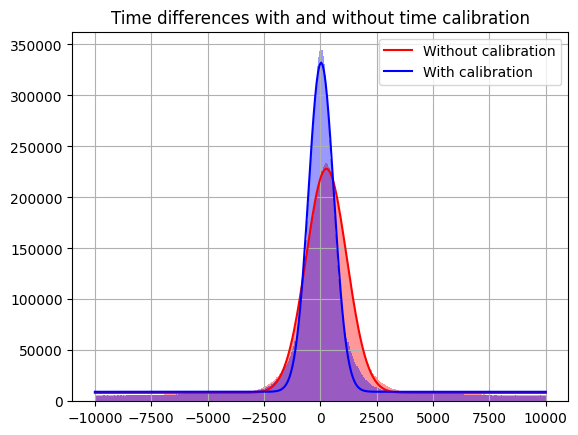

In [6]:
# Define gaussian fit
def gaussiannoise(x, a, mu, c, noise):
    return a * np.exp(-(x - mu)**2 / (2 * c**2)) + noise

# Histogram before time calibration
hist_before = plt.hist(master_time_diffs, bins=range(int(min(master_time_diffs)), int(max(master_time_diffs)) + binwidth, binwidth), color = 'red', alpha = 0.4)
bincenters0 = [(hist_before[1][x]+hist_before[1][x+1])/2 for x in range(len(hist_before[0]))]
popt0 = curve_fit(gaussiannoise, bincenters0, hist_before[0], p0 = [300000, 0, 1000, 10000])[0]
plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), gaussiannoise(np.linspace(-1*histogramlim, histogramlim, 300), *popt0), color = 'red', label = 'Without calibration')
print(popt0)

# Histogram of dummy data
hist_dummy = plt.hist(master_time_diffs1, bins=range(int(min(master_time_diffs1)), int(max(master_time_diffs1)) + binwidth, binwidth), color = 'blue', alpha = 0.4)
bincenters1 = [(hist_dummy[1][x]+hist_dummy[1][x+1])/2 for x in range(len(hist_dummy[0]))]
popt1 = curve_fit(gaussiannoise, bincenters1, hist_dummy[0], p0 = [500000, 0, 500, 10000])[0]
plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), gaussiannoise(np.linspace(-1*histogramlim, histogramlim, 300), *popt1), color = 'blue', label = 'With calibration')
print(popt1)

plt.legend()
plt.title('Time differences with and without time calibration')
plt.grid()
#plt.savefig('C:/Users/burri/Downloads/' + 'TPPTcalibrationtest2.png')
plt.show()

[213612.05351869    254.58309293    850.38241261   9948.47917006
    325.41570978   2763.16326649   5869.76051182]
[3.50423537e+05 3.23652709e+01 3.05471046e+02 9.35860920e+04
 4.35142889e+01 9.90554205e+02 7.04569368e+03]


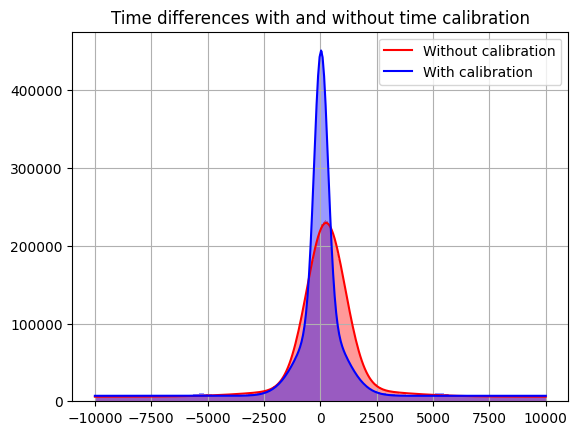

In [ ]:
# Double gaussian fit
def doublegaussian(x, a1, mu1, c1, a2, mu2, c2, noise):
    return a1 * np.exp(-(x - mu1)**2 / (2 * c1**2)) + a2 * np.exp(-(x - mu2)**2 / (2 * c2**2)) + noise

# Histogram before time calibration
hist_before = plt.hist(master_time_diffs, bins=range(int(min(master_time_diffs)), int(max(master_time_diffs)) + binwidth, binwidth), color = 'red', alpha = 0.4)
bincenters0 = [(hist_before[1][x]+hist_before[1][x+1])/2 for x in range(len(hist_before[0]))]
popt0 = curve_fit(doublegaussian, bincenters0, hist_before[0], p0 = [200000, 0, 1000, 50000, 0, 2000, 10000])[0]
plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), doublegaussian(np.linspace(-1*histogramlim, histogramlim, 300), *popt0), color = 'red', label = 'Without calibration')
print(popt0)

# Histogram of dummy data
hist_dummy = plt.hist(master_time_diffs1, bins=range(int(min(master_time_diffs1)), int(max(master_time_diffs1)) + binwidth, binwidth), color = 'blue', alpha = 0.4)
bincenters1 = [(hist_dummy[1][x]+hist_dummy[1][x+1])/2 for x in range(len(hist_dummy[0]))]
popt1 = curve_fit(doublegaussian, bincenters1, hist_dummy[0], p0 = [200000, 0, 1000, 50000, 0, 2000, 10000])[0]
plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), doublegaussian(np.linspace(-1*histogramlim, histogramlim, 300), *popt1), color = 'blue', label = 'With calibration')
print(popt1)

plt.legend()
plt.title('Time differences with and without time calibration')
plt.grid()
#plt.savefig('C:/Users/burri/Documents/PET/TimeCalibration/TimeCalibrationTPPT/' + 'TPPT_timecal_Run2_tsv1.png')
plt.show()

[213612.05351869    254.58309293    850.38241261   9948.47917006
    325.41570978   2763.16326649   5869.76051182]


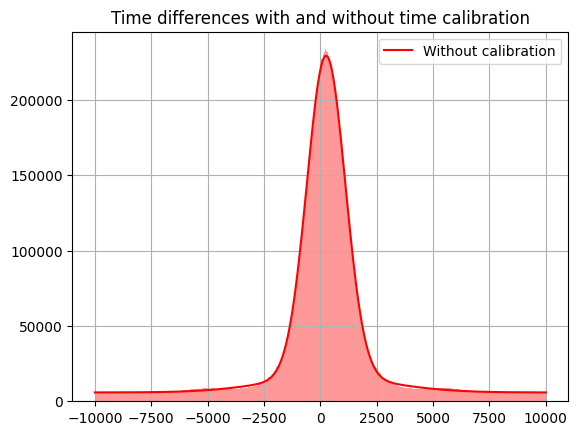

In [5]:
# Double gaussian fit
def doublegaussian(x, a1, mu1, c1, a2, mu2, c2, noise):
    return a1 * np.exp(-(x - mu1)**2 / (2 * c1**2)) + a2 * np.exp(-(x - mu2)**2 / (2 * c2**2)) + noise

# Histogram before time calibration
hist_before = plt.hist(master_time_diffs, bins=range(int(min(master_time_diffs)), int(max(master_time_diffs)) + binwidth, binwidth), color = 'red', alpha = 0.4)
bincenters0 = [(hist_before[1][x]+hist_before[1][x+1])/2 for x in range(len(hist_before[0]))]
popt0 = curve_fit(doublegaussian, bincenters0, hist_before[0], p0 = [200000, 0, 1000, 50000, 0, 2000, 10000])[0]
plt.plot(np.linspace(-1*histogramlim, histogramlim, 300), doublegaussian(np.linspace(-1*histogramlim, histogramlim, 300), *popt0), color = 'red', label = 'Without calibration')
print(popt0)

residuals = hist_before[0] - doublegaussian(bincenters0, *popt0)
chi2 = np.sum(residuals**2)
chi2_reduced = chi2 / (len(hist_before[0]) - len(popt0))

plt.legend()
plt.title('Time differences with and without time calibration')
plt.grid()
#plt.savefig('C:/Users/burri/Documents/PET/TimeCalibration/TimeCalibrationTPPT/' + 'TPPT_timecal_Run2_tsv1.png')
plt.show()

In [10]:
print(len(hist_before[0]))

400
